### Front matter

---
### exercise: resolucao_data
### ai_use: "Gemini no código de geração de dados e gráficos; a análise é minha juntamente com o perceptron implementado."
---

# Exercício 1
## A — Generate the data 

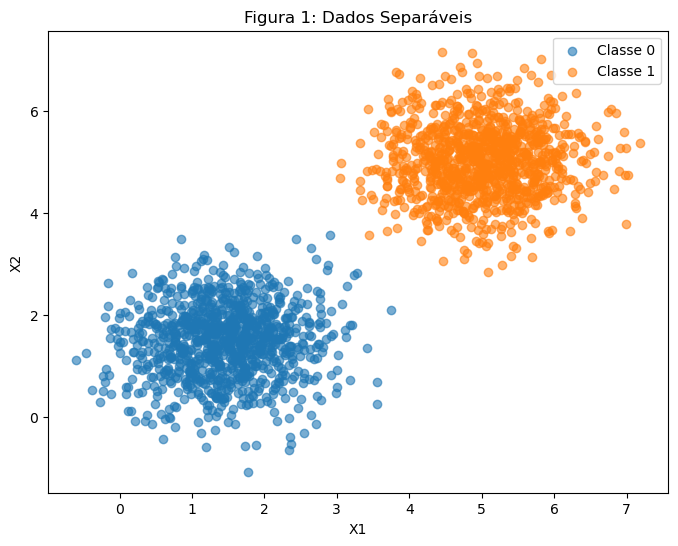

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Regra 1: Fixar a semente globalmente
rng = np.random.default_rng(42)

# A - Geração de Dados
X0 = rng.multivariate_normal([1.5, 1.5], [[0.5, 0], [0, 0.5]], 1000)
X1 = rng.multivariate_normal([5, 5], [[0.5, 0], [0, 0.5]], 1000)
X_sep = np.vstack((X0, X1))
y_sep = np.concatenate((np.zeros(1000), np.ones(1000)))

# Figura 1: Dispersão
plt.figure(figsize=(8, 6))
plt.scatter(X0[:, 0], X0[:, 1], label='Classe 0', alpha=0.6)
plt.scatter(X1[:, 0], X1[:, 1], label='Classe 1', alpha=0.6)
plt.title('Figura 1: Dados Separáveis')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

## B — Perceptron - Exercicio 1 e 2

In [3]:
def ativacao(z):
    if z >= 0:
        return 1
    else:
        return 0

def predicao(x,w,b):
    return ativacao(np.dot(x,w) + b)

def acuracia(X, y, w, b):
    acerto = 0
    for i in range(len(X)):
        if predicao(X[i], w, b) == y[i]:
            acerto += 1
    return acerto / len(X)

def treino_perceptron(X, y, taxa_aprendizado=0.01, epocas=100):
    w = rng.normal(0,0.01, size = 2)
    b = 0
    w_pocket = w.copy()
    b_pocket = b
    acuracia_boa = acuracia(X, y, w, b)
    pocket_epoca = 0
    acuracias = []
    acurarias_pocket = []
    for epoca in range(epocas):
        atualizar = False
        for i in range(len(X)):
            y_pred = predicao(X[i], w, b)
            if y_pred != y[i]:
                erro = y[i] - y_pred
                w += taxa_aprendizado * erro * X[i]
                b += taxa_aprendizado * erro
                atualizar = True
                if acuracia(X, y, w, b) > acuracia_boa:
                    w_pocket = w.copy()
                    b_pocket = b
                    acuracia_boa = acuracia(X, y, w, b)
                    pocket_epoca = epoca + 1
        acuracias.append(acuracia(X, y, w, b))
        acurarias_pocket.append(acuracia_boa)
        if atualizar==False:
            break
    return w, b, w_pocket, b_pocket, acuracias, acurarias_pocket, pocket_epoca



## C — Treino e meça 

--- Treino  ---
Pesos finais (w): [0.05049707 0.02887168]
Bias final (b): -0.25000000000000006
Número de épocas: 26
Acurácia final: 1.0000


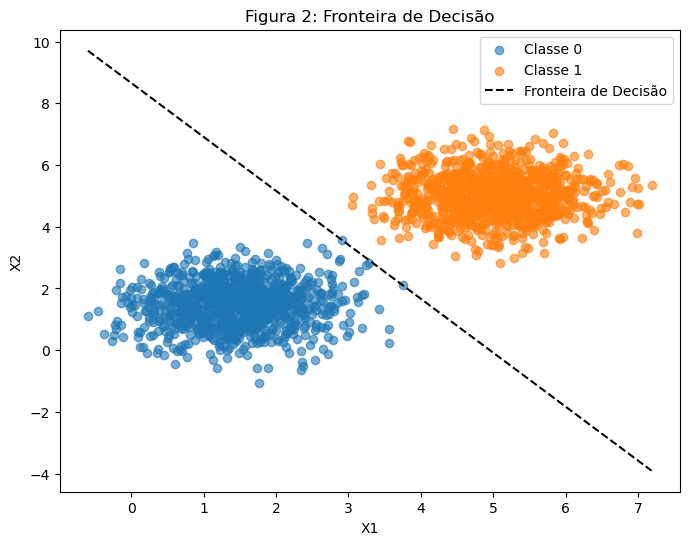

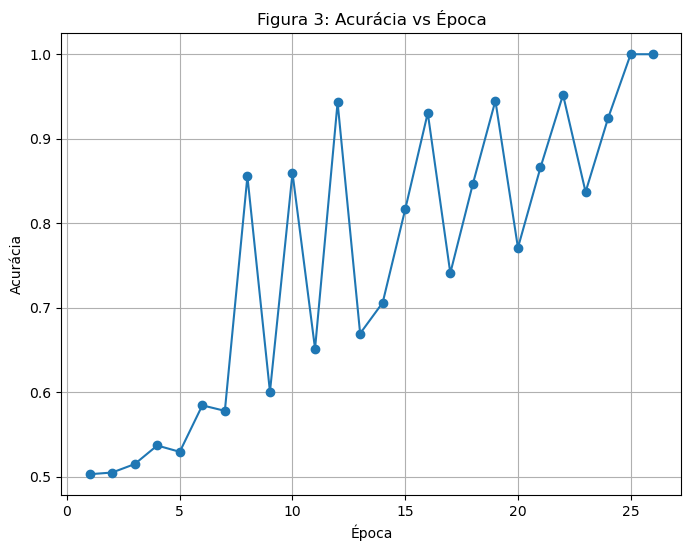

In [4]:
# 1. Treino e reporte do modelo com a taxa padrão
w_01, b_01, _, _, acc_01, _, _ = treino_perceptron(X_sep, y_sep, taxa_aprendizado=0.01)
epocas_01 = len(acc_01)

print(f"--- Treino  ---")
print(f"Pesos finais (w): {w_01}")
print(f"Bias final (b): {b_01}")
print(f"Número de épocas: {epocas_01}")
print(f"Acurácia final: {acc_01[-1]:.4f}")

# Previsões para identificar pontos mal classificados
predicoes_sep = np.array([predicao(x, w_01, b_01) for x in X_sep])
X_erros = X_sep[predicoes_sep != y_sep]

# 2. Figura 2: Fronteira de decisão
plt.figure(figsize=(8, 6))
plt.scatter(X_sep[y_sep==0][:, 0], X_sep[y_sep==0][:, 1], label='Classe 0', alpha=0.6)
plt.scatter(X_sep[y_sep==1][:, 0], X_sep[y_sep==1][:, 1], label='Classe 1', alpha=0.6)

if len(X_erros) > 0:
    plt.scatter(X_erros[:, 0], X_erros[:, 1], color='red', marker='x', s=100, label='Mal classificados')

# Calculando a reta de decisão w.x + b = 0 
x_vals = np.array([np.min(X_sep[:, 0]), np.max(X_sep[:, 0])])
y_vals = -(w_01[0] * x_vals + b_01) / w_01[1]
plt.plot(x_vals, y_vals, '--k', label='Fronteira de Decisão')

plt.title('Figura 2: Fronteira de Decisão')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

# 3. Figura 3: Acurácia x Época
plt.figure(figsize=(8, 6))
plt.plot(range(1, epocas_01 + 1), acc_01, marker='o')
plt.title('Figura 3: Acurácia vs Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.grid(True)
plt.show()

### D — Análise
1. **Convergência de dados separáveis**: A reta de decisão acha rapidamente o espaço vazio entre as duas classes. Como a regra do perceptron só muda os valores quando ele erra uma classificação, a quantidade de atualizações vai caindo a cada época até zerar, e aí o treino simplesmente para mais cedo.

2. **Execução com taxa maior (1.0)**: Treinar com a taxa em 0.01 ou em 1.0 chega nos 100% de acerto do mesmo jeito, mas desenha retas diferentes. Essa taxa controla o tamanho do "salto" de correção. Como a gente começa com pesos pequenos, um passo maior de 1.0 "engole" e apaga totalmente a direção que foi sorteada no começo. Contudo, ja com o passo pequeno de 0.01, a reta final ainda carrega a influência desse sorteio inicial. 

3. **Partida com pesos zerados**: Se a gente começarmos com tudo no zero absoluto, o valor final seria apenas a soma dos erros multiplicada pela taxa de aprendizado. Como a equação que define a reta é igualada a zero, essa taxa ia acabar sendo cortada dos dois lados na matemática básica. Ou seja, a reta de decisão e as épocas seriam exatamente iguais para qualquer taxa escolhida, e ela perderia totalmente a utilidade. Devido a isso, não podemos começar do zero a nossa analise.

# Exercício 2
## A — Gere os dados


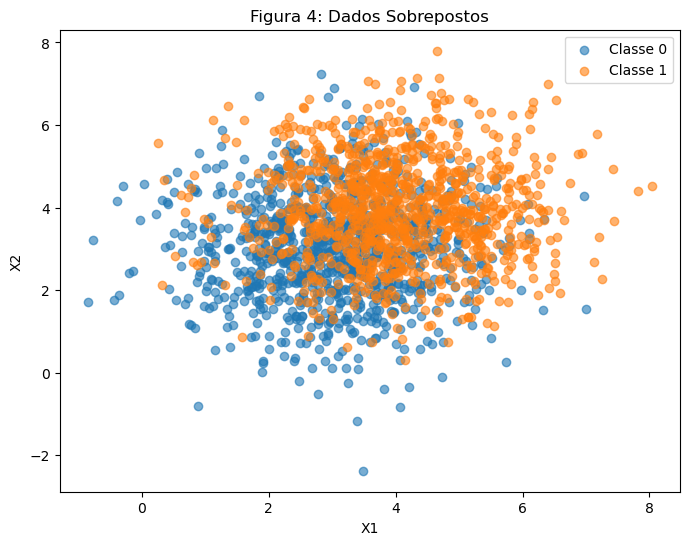

In [5]:
X0_ov = rng.multivariate_normal([3, 3], [[1.5, 0], [0, 1.5]], 1000)
X1_ov = rng.multivariate_normal([4, 4], [[1.5, 0], [0, 1.5]], 1000)
X_ov = np.vstack((X0_ov, X1_ov))
y_ov = np.concatenate((np.zeros(1000), np.ones(1000)))

plt.figure(figsize=(8, 6))
plt.scatter(X0_ov[:, 0], X0_ov[:, 1], label='Classe 0', alpha=0.6)
plt.scatter(X1_ov[:, 0], X1_ov[:, 1], label='Classe 1', alpha=0.6)
plt.title('Figura 4: Dados Sobrepostos')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

## B e C— Treine guardando os melhores pesos


--- Resultados do Exercício 2 ---
Pesos Finais (w): [0.05175095 0.03623543]
Viés Final (b): -0.07
Acurácia dos Pesos Finais: 0.5020

Pesos do Pocket (w): [0.01384997 0.00953569]
Viés do Pocket (b): -0.08
Acurácia do Pocket: 0.7125 (Ocorreu na época 98)


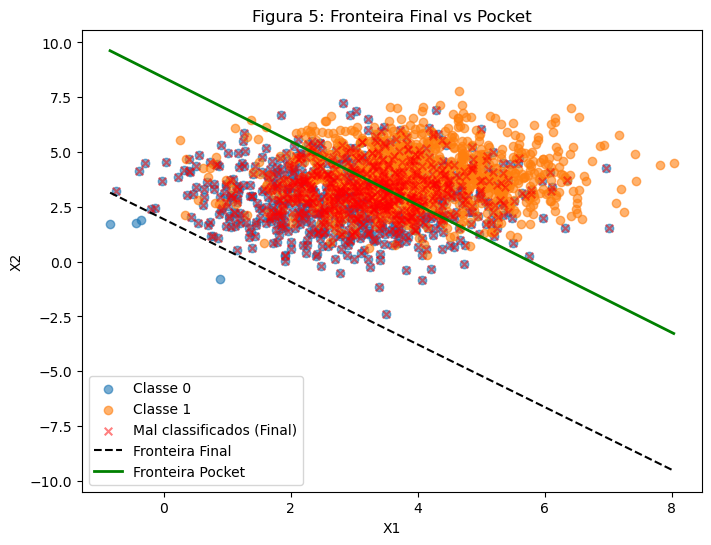

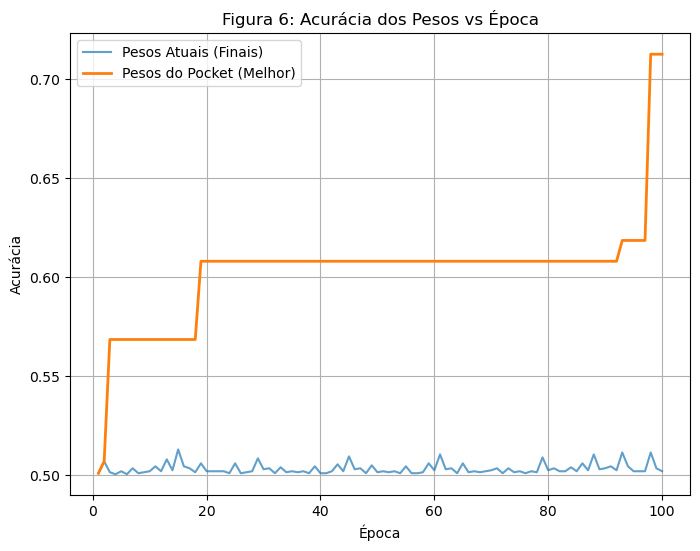

In [10]:
# Executando o treino do Exercício 2 (Com a atribuição correta das 7 variáveis)
w_final, b_final, w_pocket, b_pocket, hist_acc, hist_pck, epoca_pck = treino_perceptron(X_ov, y_ov, taxa_aprendizado=0.01)

# Acurácia final do pocket (pegamos o último valor do histórico do pocket)
acc_pocket = hist_pck[-1]

print("--- Resultados do Exercício 2 ---")
print(f"Pesos Finais (w): {w_final}")
print(f"Viés Final (b): {b_final}")
print(f"Acurácia dos Pesos Finais: {hist_acc[-1]:.4f}")
print(f"\nPesos do Pocket (w): {w_pocket}")
print(f"Viés do Pocket (b): {b_pocket}")
print(f"Acurácia do Pocket: {acc_pocket:.4f} (Ocorreu na época {epoca_pck})")

# Figura 5: As duas fronteiras de decisão 
predicoes_finais = np.array([predicao(x, w_final, b_final) for x in X_ov])
erros_finais = X_ov[predicoes_finais != y_ov]

plt.figure(figsize=(8, 6))
plt.scatter(X0_ov[:, 0], X0_ov[:, 1], label='Classe 0', alpha=0.6)
plt.scatter(X1_ov[:, 0], X1_ov[:, 1], label='Classe 1', alpha=0.6)

if len(erros_finais) > 0:
    plt.scatter(erros_finais[:, 0], erros_finais[:, 1], color='red', marker='x', s=30, alpha=0.5, label='Mal classificados (Final)')

x_vals_ov = np.array([np.min(X_ov[:, 0]), np.max(X_ov[:, 0])])

# Reta Final
y_vals_final = -(w_final[0] * x_vals_ov + b_final) / w_final[1]
plt.plot(x_vals_ov, y_vals_final, '--k', label='Fronteira Final')

# Reta Pocket
y_vals_pocket = -(w_pocket[0] * x_vals_ov + b_pocket) / w_pocket[1]
plt.plot(x_vals_ov, y_vals_pocket, '-g', linewidth=2, label='Fronteira Pocket')

plt.title('Figura 5: Fronteira Final vs Pocket')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

# Figura 6: Duas curvas contra a época 
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(hist_acc) + 1), hist_acc, label='Pesos Atuais (Finais)', alpha=0.7)
plt.plot(range(1, len(hist_pck) + 1), hist_pck, label='Pesos do Pocket (Melhor)', linewidth=2)
plt.title('Figura 6: Acurácia dos Pesos vs Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

### D — Análise
1. **Diferença final vs. pocket**: O pocket guarda a melhor reta encontrada cerca de 73% de acerto, mas a final termina em cerca de 50%. Como os dados se misturam, cada erro gera um uma compensação forte sobre o resultado o que estraga a formação da reta.
2. **Separabilidade**: O perceptron só converge se os dados forem linearmente separáveis, com isso este conjunto de dados viola essa regra, sendo muito mais proximos e não dispersos, fazendo a acuracia oscilar frequentemente.
3. **Mais epocas ou menor taxa**: Diretamente estes não resolvem, mais epocas apenas prolongam a oscilação dentro dos resultados, e uma taxa menor reduz o passo na mesma proporção em que diminui os pesos,assim acabando ficando sem corrigir.

## Tabela de resultados

In [19]:
w_sep, b_sep, _, _, hist_acc_sep, _, _ = treino_perceptron(X_sep, y_sep, taxa_aprendizado=0.1)
epocas_sep = len(hist_acc_sep)

w_10, b_10, _, _, acc_10, _, _ = treino_perceptron(X_sep, y_sep, taxa_aprendizado=1.0)
epocas_10 = len(acc_10)

# Executando o treino do Exercício 2 (com o teu pocket)
w_final, b_final, w_pocket, b_pocket, hist_acc, hist_pck, epoca_pck = treino_perceptron(X_ov, y_ov, taxa_aprendizado=0.01)

# Montando a tabela de resumo idêntica à pedida pelo professor
dados_tabela = [
    {"#": 1, "Quantidade": "Exercício 1 - w e b finais", "Valor": f"w = {w_sep.round(4)}, b = {b_sep:.4f}"},
    {"#": 2, "Quantidade": "Exercício 1 - épocas até convergir", "Valor": f"{epocas_sep}"},
    {"#": 3, "Quantidade": "Exercício 1 - acurácia final", "Valor": f"{hist_acc_sep[-1]:.4f}"},
    {"#": 4, "Quantidade": "Exercício 1 - épocas e acurácia final com η = 1.0", "Valor": f"{epocas_10} épocas, Acc: {acc_10[-1]:.4f}"},
    {"#": 5, "Quantidade": "Exercício 2 - w e b finais", "Valor": f"w = {w_final.round(4)}, b = {b_final:.4f}"},
    {"#": 6, "Quantidade": "Exercício 2 - acurácia dos pesos finais", "Valor": f"{hist_acc[-1]:.4f}"},
    {"#": 7, "Quantidade": "Exercício 2 - acurácia dos pesos do pocket", "Valor": f"{hist_pck[-1]:.4f}"},
    {"#": 8, "Quantidade": "Exercício 2 - época em que o melhor do pocket ocorreu", "Valor": f"Época {epoca_pck}"}
]

df_resumo = pd.DataFrame(dados_tabela)
df_resumo.set_index("#", inplace=True)



In [20]:
display(df_resumo)

,Quantidade,Valor
#,,
1,Exercício 1 - w e b finais,"w = [0.5299 0.367 ], b = -3.0000"
2,Exercício 1 - épocas até convergir,35
3,Exercício 1 - acurácia final,1.0000
4,Exercício 1 - épocas e acurácia final com η = 1.0,"15 épocas, Acc: 1.0000"
5,Exercício 2 - w e b finais,"w = [0.052 0.0379], b = -0.0700"
6,Exercício 2 - acurácia dos pesos finais,0.5020
7,Exercício 2 - acurácia dos pesos do pocket,0.7165
8,Exercício 2 - época em que o melhor do pocket ...,Época 63
